# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Mounting the Google drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Reading Dataset

In [3]:
try:
    df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Fifa20 project/players_20.csv')
except FileNotFoundError:
    print("Error: The file was not found at the specified path.")
    print("Please check the file path and ensure the file exists in your Google Drive.")

In [4]:
df.head()

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,32,1987-06-24,170,72,Argentina,FC Barcelona,...,68+2,66+2,66+2,66+2,68+2,63+2,52+2,52+2,52+2,63+2
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,34,1985-02-05,187,83,Portugal,Juventus,...,65+3,61+3,61+3,61+3,65+3,61+3,53+3,53+3,53+3,61+3
2,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Junior,27,1992-02-05,175,68,Brazil,Paris Saint-Germain,...,66+3,61+3,61+3,61+3,66+3,61+3,46+3,46+3,46+3,61+3
3,200389,https://sofifa.com/player/200389/jan-oblak/20/...,J. Oblak,Jan Oblak,26,1993-01-07,188,87,Slovenia,Atlético Madrid,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,183277,https://sofifa.com/player/183277/eden-hazard/2...,E. Hazard,Eden Hazard,28,1991-01-07,175,74,Belgium,Real Madrid,...,66+3,63+3,63+3,63+3,66+3,61+3,49+3,49+3,49+3,61+3


# Checking for missing values

In [5]:
# 1. Missing values count
missing_count = df.isnull().sum()

# 2. Percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100

# 3. Combine into one table
missing_data = pd.DataFrame({
    'Missing Values': missing_count,
    'Percentage': missing_percentage
}).sort_values(by='Percentage', ascending=False)

pd.set_option('display.max_rows', None)    # for showing all the rows and columns without limit.
pd.set_option('display.max_columns',None)

print(missing_data)


                            Missing Values  Percentage
loaned_from                          17230   94.266331
nation_position                      17152   93.839589
nation_jersey_number                 17152   93.839589
player_tags                          16779   91.798884
gk_kicking                           16242   88.860926
gk_diving                            16242   88.860926
gk_handling                          16242   88.860926
gk_reflexes                          16242   88.860926
gk_speed                             16242   88.860926
gk_positioning                       16242   88.860926
player_traits                        10712   58.605974
defending                             2036   11.139074
pace                                  2036   11.139074
passing                               2036   11.139074
dribbling                             2036   11.139074
rs                                    2036   11.139074
lam                                   2036   11.139074
cam       

# Droping Columns
- Drop only those columns where percentage of missing values is higher than 50%.

In [6]:
df.drop(['loaned_from','nation_position','nation_jersey_number','player_tags','gk_diving','gk_kicking','gk_handling','gk_speed','gk_positioning','gk_reflexes'],axis=1,inplace=True)

# Filling the Missing values with mean and mode

In [7]:
df.head(2)

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,overall,potential,value_eur,wage_eur,player_positions,preferred_foot,international_reputation,weak_foot,skill_moves,work_rate,body_type,real_face,release_clause_eur,team_position,team_jersey_number,joined,contract_valid_until,pace,shooting,passing,dribbling,defending,physic,player_traits,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,ram,lm,lcm,cm,rcm,rm,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,32,1987-06-24,170,72,Argentina,FC Barcelona,94,94,95500000,565000,"RW, CF, ST",Left,5,4,4,Medium/Low,Messi,Yes,195800000.0,RW,10.0,2004-07-01,2021.0,87.0,92.0,92.0,96.0,39.0,66.0,"Beat Offside Trap, Argues with Officials, Earl...",88,95,70,92,88,97,93,94,92,96,91,84,93,95,95,86,68,75,68,94,48,40,94,94,75,96,33,37,26,6,11,15,14,8,89+2,89+2,89+2,93+2,93+2,93+2,93+2,93+2,93+2,93+2,93+2,92+2,87+2,87+2,87+2,92+2,68+2,66+2,66+2,66+2,68+2,63+2,52+2,52+2,52+2,63+2
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,34,1985-02-05,187,83,Portugal,Juventus,93,93,58500000,405000,"ST, LW",Right,5,4,5,High/Low,C. Ronaldo,Yes,96500000.0,LW,7.0,2018-07-10,2022.0,90.0,93.0,82.0,89.0,35.0,78.0,"Long Throw-in, Selfish, Argues with Officials,...",84,94,89,83,87,89,81,76,77,92,89,91,87,96,71,95,95,85,78,93,63,29,95,82,85,95,28,32,24,7,11,15,14,11,91+3,91+3,91+3,89+3,90+3,90+3,90+3,89+3,88+3,88+3,88+3,88+3,81+3,81+3,81+3,88+3,65+3,61+3,61+3,61+3,65+3,61+3,53+3,53+3,53+3,61+3


In [8]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

print("Numerical Columns:", len(num_cols))
print("Categorical columns:",len(cat_cols))

Numerical Columns: 54
Categorical columns: 40


In [9]:
# # Checking percentage of missing values in the columns
# print(((df.isnull().sum()/len(df)) *100).sort_values(ascending=False))

In [10]:
# classifying those columns into numerical and categorical columns


columns_to_classify = [
    'player_traits', 'pace', 'shooting', 'lf', 'lw', 'passing', 'lam', 'cam',
    'rw', 'rf', 'cm', 'lcm', 'lm', 'rs', 'cdm', 'rdm', 'rwb', 'lb', 'lcb', 'cb',
    'lwb', 'ldm', 'rcb', 'rb', 'rm', 'rcm', 'physic', 'defending', 'dribbling',
    'ram', 'st', 'ls', 'cf', 'release_clause_eur', 'joined', 'contract_valid_until',
    'team_position', 'team_jersey_number'
]

numerical_cols = df[columns_to_classify].select_dtypes(include=np.number).columns.tolist()
categorical_cols = df[columns_to_classify].select_dtypes(include='object').columns.tolist()

print("Numerical Columns:", numerical_cols)
print("\nCategorical Columns:", categorical_cols)

Numerical Columns: ['pace', 'shooting', 'passing', 'physic', 'defending', 'dribbling', 'release_clause_eur', 'contract_valid_until', 'team_jersey_number']

Categorical Columns: ['player_traits', 'lf', 'lw', 'lam', 'cam', 'rw', 'rf', 'cm', 'lcm', 'lm', 'rs', 'cdm', 'rdm', 'rwb', 'lb', 'lcb', 'cb', 'lwb', 'ldm', 'rcb', 'rb', 'rm', 'rcm', 'ram', 'st', 'ls', 'cf', 'joined', 'team_position']


##improved version of imputation

In [11]:
# 1. Robust Imputation Example
def robust_impute(df, num_cols, cat_cols):
    for col in num_cols:
        if df[col].notnull().any():
            df[col] = df[col].fillna(df[col].mean())
    for col in cat_cols:
        if df[col].notnull().any():
            df[col] = df[col].fillna(df[col].mode()[0])
    return df

# Usage:
df = robust_impute(df, num_cols, cat_cols)

In [12]:
# 2. Outlier Capping Example (IQR)
def cap_outliers(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower, upper)
    return df

# Usage:
df = cap_outliers(df, numerical_cols)

In [13]:
# 3. Visualization Enhancement Example
print('Summary statistics before transformation:')
print(df[numerical_cols].describe())

# After transformation (run after you apply transformations)
print('Summary statistics after transformation:')
print(df[numerical_cols].describe())

Summary statistics before transformation:
               pace      shooting       passing        physic     defending  \
count  18278.000000  18278.000000  18278.000000  18278.000000  18278.000000   
mean      67.980908     52.298082     57.288487     64.955817     51.553503   
std        9.844902     13.222462      9.547628      8.986602     15.477991   
min       46.500000     17.000000     35.500000     43.500000     15.000000   
25%       63.000000     44.000000     52.000000     60.000000     39.000000   
50%       67.700899     52.298301     57.233777     64.876678     52.000000   
75%       74.000000     62.000000     63.000000     71.000000     64.000000   
max       90.500000     89.000000     79.500000     87.500000     90.000000   

          dribbling  release_clause_eur  contract_valid_until  \
count  18278.000000        1.827800e+04          18278.000000   
mean      62.716890        3.072997e+06           2021.114427   
std        9.159697        3.493661e+06            

In [14]:
# 4. Modularity Example: General Imputation Function
def impute_missing(df, cols, method='mean'):
    for col in cols:
        if method == 'mean':
            df[col] = df[col].fillna(df[col].mean())
        elif method == 'median':
            df[col] = df[col].fillna(df[col].median())
        elif method == 'mode':
            df[col] = df[col].fillna(df[col].mode()[0])
    return df

# Usage:
df = impute_missing(df, num_cols, method='mean')
df = impute_missing(df, cat_cols, method='mode')

In [15]:
# Example: Error Handling for Transformations
from scipy.stats import boxcox
for col in numerical_cols:
    try:
        if (df[col] <= 0).any():
            df[col] = boxcox(df[col] + 1)[0]
        else:
            df[col] = boxcox(df[col])[0]
    except Exception as e:
        print(f"Transformation failed for {col}: {e}")

In [16]:
from scipy.stats import boxcox

for col in numerical_cols:
    try:
        if df[col].nunique() == 1:
            print(f"Skipping transformation for {col}: column is constant.")
            continue
        if (df[col] <= 0).any():
            df[col] = boxcox(df[col] + 1)[0]
        else:
            df[col] = boxcox(df[col])[0]
    except Exception as e:
        print(f"Transformation failed for {col}: {e}")

Skipping transformation for contract_valid_until: column is constant.


In [17]:
print(df.isnull().sum())  # Should show all zeros if missing values are handled

sofifa_id                     0
player_url                    0
short_name                    0
long_name                     0
age                           0
dob                           0
height_cm                     0
weight_kg                     0
nationality                   0
club                          0
overall                       0
potential                     0
value_eur                     0
wage_eur                      0
player_positions              0
preferred_foot                0
international_reputation      0
weak_foot                     0
skill_moves                   0
work_rate                     0
body_type                     0
real_face                     0
release_clause_eur            0
team_position                 0
team_jersey_number            0
joined                        0
contract_valid_until          0
pace                          0
shooting                      0
passing                       0
dribbling                     0
defendin

In [18]:
print(df.describe())

           sofifa_id           age     height_cm     weight_kg       overall  \
count   18278.000000  18278.000000  18278.000000  18278.000000  18278.000000   
mean   219738.864482     25.283291    181.362184     75.276343     66.244994   
std     27960.200461      4.656964      6.756961      7.047744      6.949953   
min       768.000000     16.000000    156.000000     50.000000     48.000000   
25%    204445.500000     22.000000    177.000000     70.000000     62.000000   
50%    226165.000000     25.000000    181.000000     75.000000     66.000000   
75%    240795.750000     29.000000    186.000000     80.000000     71.000000   
max    252905.000000     42.000000    205.000000    110.000000     94.000000   

          potential     value_eur       wage_eur  international_reputation  \
count  18278.000000  1.827800e+04   18278.000000              18278.000000   
mean      71.546887  2.484038e+06    9456.942773                  1.103184   
std        6.139669  5.585481e+06   21351.714

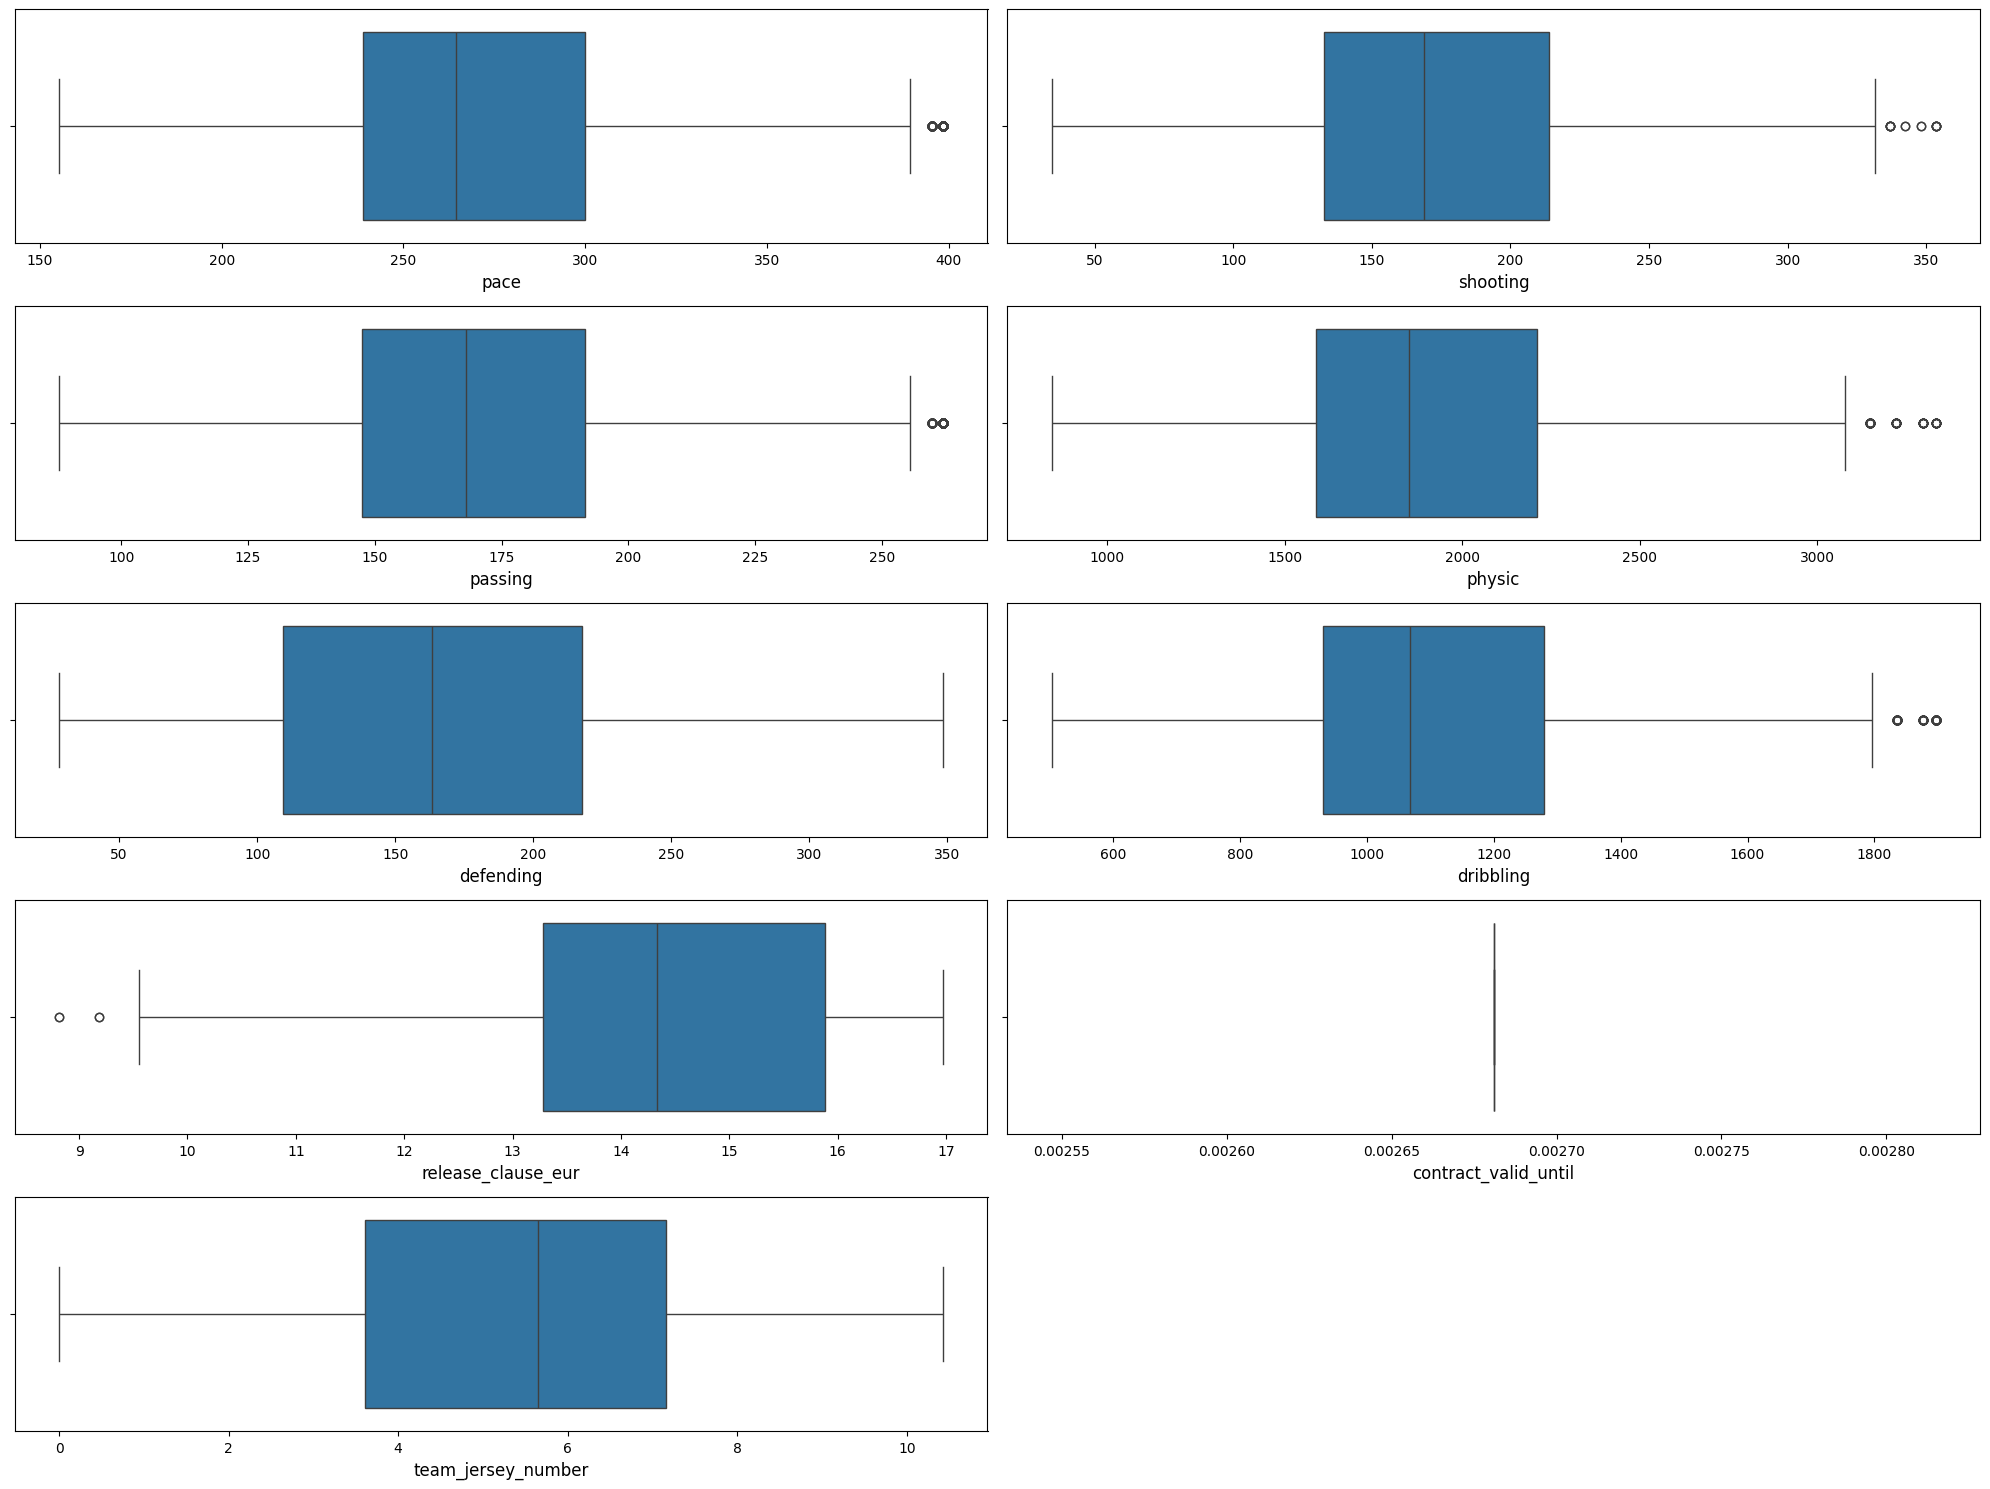

In [19]:
    import matplotlib.pyplot as plt
    import seaborn as sns
    plt.figure(figsize=(20, 15), facecolor='white')
    plotnumber = 1

    for col in numerical_cols:
        if plotnumber <= len(numerical_cols):
           ax = plt.subplot(5, int(len(numerical_cols)/5)+1, plotnumber)
           sns.boxplot(x=df[col])
           plt.xlabel(col, fontsize=12)
        plotnumber += 1

    plt.tight_layout()
    plt.show()

## Label encoding for categorical columns

In [20]:
from sklearn.preprocessing import LabelEncoder
df_encoded = pd.get_dummies(df,columns=categorical_cols , drop_first=True)

le = LabelEncoder()
for col in categorical_cols:
    if df[col].nunique() <= 10:  # Example threshold for label encoding
        df[col] = le.fit_transform(df[col].astype(str))
print('Categorical encoding complete.')


Categorical encoding complete.


## feature Creation

In [21]:
#Ratio features (e.g., pace/shooting) help compare player attributes

df['pace_to_shooting'] = df['pace'] / (df['shooting'] + 1e-9)
df['passing_to_dribbling'] = df['passing'] / (df['dribbling'] + 1e-9)

#Interaction features (e.g., physic * defending) capture combined effects

df['physic_x_defending'] = df['physic'] * df['defending']
print('Feature creation complete.')

Feature creation complete.


# Feature Selection

In [22]:
#  Feature Selection
# Removing low-variance features
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=0.01)
df_var = selector.fit_transform(df.select_dtypes(include=[np.number]))
print('Low-variance features removed.')



Low-variance features removed.


In [23]:
# Removing highly correlated features (correlation > 0.95)
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
df = df.drop(columns=to_drop)
print('Highly correlated features removed:', to_drop)

Highly correlated features removed: ['defending_sliding_tackle', 'goalkeeping_handling', 'goalkeeping_kicking', 'goalkeeping_positioning', 'goalkeeping_reflexes']


## Standardization

In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
print('Numerical features standardized.')



Numerical features standardized.


# Normalization

In [25]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
print('Numerical features normalized.')

Numerical features normalized.


# Saving Processed dataset

In [27]:
df.to_csv('/content/drive/MyDrive/Colab Notebooks/Fifa20 project/cleaned_data.csv', index=False)
print("✅ Cleaned and processed data saved successfully!")


✅ Cleaned and processed data saved successfully!


# Feature Engineering Completed